# Beyond the familiar
### A small experiment in topic discovery

Enter a few interests, define what counts as familiar, and search a controlled distance beyond that region. Every recommendation comes from a fixed catalog of meaningful topic phrases and descriptions.

**Start:** choose **Run All**. The first run downloads the public MPNet embedding model; subsequent inference runs locally, with no API key. Use the project's `.venv` kernel. If dependencies are missing, run `%pip install -r requirements.txt` in a cell, then restart the kernel.

The reusable search code lives in `explorer.py`. A future website can call the same functions; this notebook is the current experiment.

**New:** [Jump to specific ideas and feedback](#specific-discovery) for concrete concepts reached through sourced category paths.

In [1]:
%matplotlib inline
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".cache" / "matplotlib"))
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
from explorer import (
    MODEL_NAME, load_catalog, load_model, topic_texts, interest_texts,
    parse_interests, score_catalog, nearest_topics, recommend,
)

plt.rcParams.update({"figure.dpi": 115, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})
pd.set_option("display.max_colwidth", 110)

## 1. Inspect a more balanced concept catalog

The default catalog combines authored everyday interests with concepts selected from [Wikimedia's cross-disciplinary curated list](https://meta.wikimedia.org/wiki/List_of_articles_every_Wikipedia_should_have/Expanded), using [Wikidata descriptions](https://www.wikidata.org/wiki/Wikidata:Licensing).

Each of **23 broad domains has a maximum of 160 topics**. The importer rotates through subtopics instead of allowing a large science or medical section to consume the catalog. Short domains stay short; entries are not invented to fill quotas. This balances counts, not cultural neutrality or guaranteed relevance.

The previous OpenAlex-heavy catalog is preserved in `data/archives/topics_openalex.json`. The default search reads the new fixed local `data/topics.json`; it makes no Wikimedia requests. See `data/catalog_metadata.json` for counts and provenance.

3,452 topics · 23 domains


,Topics
source,
ProductSpace,718
Wikidata,2734


,topic,domain,description
1451,Nuclear power,Engineering & transport,power generated from nuclear reactions
51,Perspective taking,Mind & behavior,Considering situations from another person's position and experience.
567,Business strategy,Economics & organizations,Choosing how organizations pursue goals within their environments.
1612,Blue cheese,Food & agriculture,cheese made with cultures of the mold Penicillium roqueforti
1164,Aeolian processes,Earth & environment,processes due to wind activity
1094,Hypertext Transfer Protocol,Computing & information,application-layer protocol for transferring web resources
229,Sampling in music,Music & performance,Reusing recorded sounds as material for musical creation.
298,Fencing,Games & sports,Exploring tactical contests with specialized sporting swords.


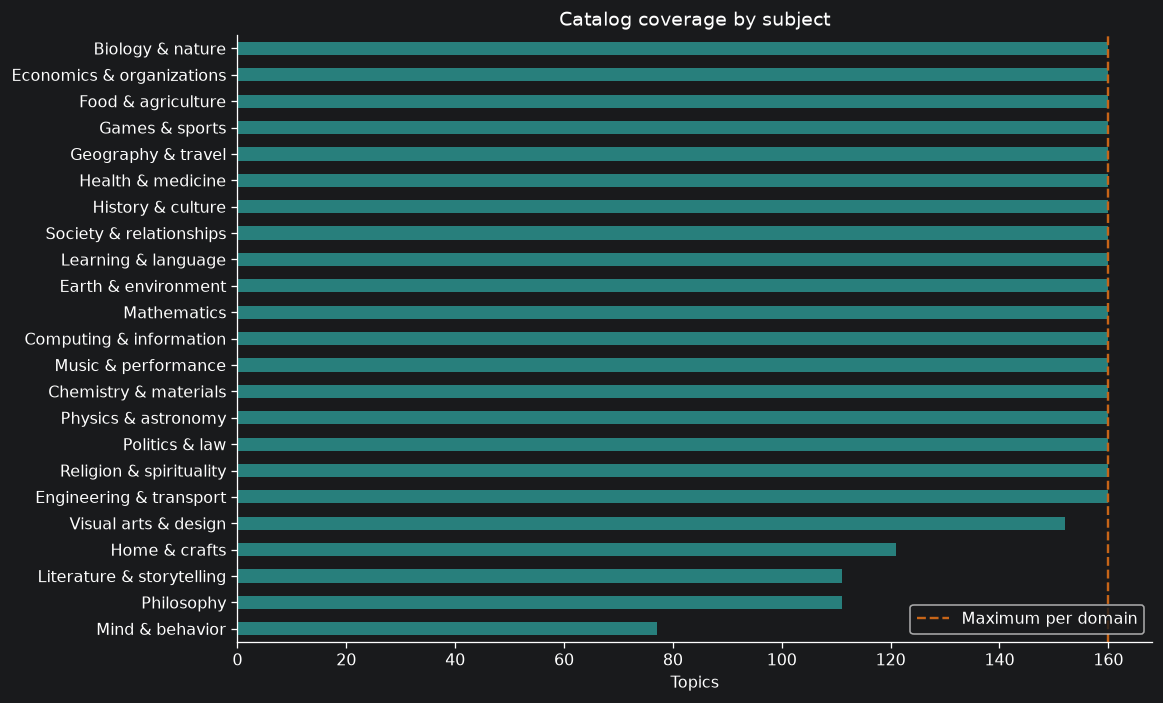

In [2]:
topics = load_catalog()
catalog = pd.DataFrame(topics)
print(f"{len(catalog):,} topics · {catalog['domain'].nunique()} domains")
display(catalog.groupby("source").size().rename("Topics").to_frame())
display(catalog.sample(8, random_state=42)[["topic", "domain", "description"]])
domain_counts = catalog.groupby("domain").size().sort_values()
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
domain_counts.plot.barh(ax=ax, color="#287f7c")
ax.axvline(160, color="#c76518", linestyle="--", label="Maximum per domain")
ax.set(title="Catalog coverage by subject", xlabel="Topics", ylabel="")
ax.legend()
plt.show()

## 2. Embed the catalog

[all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) maps the contextual topic texts to 768-dimensional vectors. Embeddings are normalized so their directions can be compared. The catalog is encoded once per notebook run; the model weights stay in the project's `.cache/models` directory.

In [3]:
model = load_model()
topic_vectors = model.encode(topic_texts(topics), normalize_embeddings=True, show_progress_bar=False)
print(f"Model: {MODEL_NAME}")
print(f"Embedding matrix: {topic_vectors.shape}")
display(pd.DataFrame(topic_vectors[:5, :6], index=catalog['topic'].head(5),
                     columns=[f"dimension {i}" for i in range(6)]))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model: sentence-transformers/all-mpnet-base-v2
Embedding matrix: (3452, 768)


,dimension 0,dimension 1,dimension 2,dimension 3,dimension 4,dimension 5
topic,,,,,,
Gardening,0.014095,0.015767,-0.010612,0.009449,-0.003216,0.006125
Urban gardening,0.022163,0.091839,-0.005691,0.040768,0.025480,0.015476
Permaculture,-0.001313,0.057062,-0.010511,0.037741,0.022156,-0.012041
Soil ecology,0.030094,-0.015406,-0.019226,0.007974,0.003428,-0.001323
Composting,0.062455,0.095070,0.005432,0.021885,0.057951,0.008608


## 3. Define your current interest region

Each interest is the center of its own neighborhood. Their **union** is the familiar region, so a topic close to *any* interest is treated as familiar. Unrelated interests are never averaged into one artificial center.

For normalized vectors, use angular distance:

$$d(x,s)=\arccos(x\cdot s)/\pi,\qquad d_{\mathrm{nearest}}(x)=\min_i d(x,s_i).$$

With radius $r$, expansion $e$ and overlap $o$, eligible topics satisfy:

$$\max(0,r-o)\le d_{\mathrm{nearest}}(x)\le\min(1,r+e).$$

- **Radius** sets the assumed size of what is already familiar.
- **Expansion** sets the maximum acceptable distance beyond the boundary.
- **Overlap** permits a small familiar bridge. Familiar results are capped at 20% of the returned list.

The radius is a modeling choice you can experiment with. Distances are model-specific; they are not calibrated measures of personal familiarity. Exact catalog-title inputs use the catalog description for context; other phrases are embedded as written.

In [4]:
# Edit these values and rerun this cell and the cells below it.
INTERESTS = ["video games", "computer science", "artificial intelligence", "overwatch", "league of legends", "breaking bad"]
RADIUS = 0.3
EXPANSION = 0.12
OVERLAP = 0.01
TOP_K = 10
DIVERSITY = 0.3
RANDOMNESS = 0.03
SEED = 42

interests = parse_interests(INTERESTS)
seed_texts = interest_texts(interests, topics)
interest_vectors = model.encode(seed_texts, normalize_embeddings=True, show_progress_bar=False)
display(pd.DataFrame({"Your interest": interests, "Text actually embedded": seed_texts}))

,Your interest,Text actually embedded
0,video games,video games
1,computer science,Computer science: study of computation
2,artificial intelligence,Artificial intelligence: field that develops and studies software enabling machines to exhibit intelligent...
3,overwatch,overwatch
4,league of legends,league of legends
5,breaking bad,breaking bad


### Parameter compass

There is no universally best radius: it depends on the model, wording, and catalog coverage. These are practical **starting ranges**, not validated psychological thresholds.

| Control | Start | Useful exploration range | Increasing it does this |
|---|---:|---:|---|
| Radius | 0.28 | 0.22–0.32 | Treats more material as familiar and skips more direct neighbors |
| Expansion | 0.07 | 0.03–0.10 | Extends the allowed band and moves the favored distance outward |
| Overlap | 0.015 | 0–0.03 | Admits some topics just inside the boundary; the 20% count cap still applies |
| Diversity | 0.20 | 0.10–0.30 | Discourages recommendations similar to ones already selected |
| Randomness | 0.03 | 0.01–0.05 | Gives near-tied candidates a small chance to trade places |

For example, radius **0.28**, expansion **0.07**, and overlap **0.015** allow distances **0.265–0.35**, favoring around **0.315**. Radius is measured from the nearest interest; expansion and overlap are measured outward/inward from that boundary. Overlap is a distance, not a percentage. Diversity is a ranking weight, not a geometric distance.

Angular distance corresponds to cosine similarity as `cos(pi * distance)`: **0.20 → 0.81**, **0.30 → 0.59**, **0.40 → 0.31**, **0.50 → 0**. The earlier default favored about 0.40, which could already be quite loosely related.

If results feel too remote, reduce radius or expansion. If there are too few candidates, widen expansion gradually or add more specific interest phrases. A small expansion is still far away when the radius is large.

In [5]:
def show_parameter_compass(inputs, seeds, radius, expansion, overlap):
    scored = nearest_topics(topics, topic_vectors, inputs, seeds, top_k=len(topics))
    distances = np.array([r["distance"] for r in scored])
    lower, upper = max(0, radius - overlap), min(1, radius + expansion)
    target = (radius + upper) / 2
    valid = distances > 0.035
    new_count = int(np.sum(valid & (distances >= radius) & (distances <= upper)))
    overlap_count = int(np.sum(valid & (distances >= lower) & (distances < radius)))
    familiar_count = int(np.sum(distances < radius))
    print(f"Allowed band: {lower:.3f}–{upper:.3f} · Favored distance: {target:.3f} (cosine ≈ {np.cos(np.pi * target):.2f})")
    print(f"Familiar: {familiar_count} topics · Available: {new_count} new candidates + {overlap_count} overlap candidates")
    if new_count < 4:
        print("This band is sparse: consider increasing expansion by 0.02 and inspecting the results.")
    display(pd.DataFrame(scored[:6]).reindex(columns=["topic", "nearest_interest", "distance"]).round(3))


show_parameter_compass(interests, interest_vectors, RADIUS, EXPANSION, OVERLAP)

Allowed band: 0.290–0.420 · Favored distance: 0.360 (cosine ≈ 0.43)
Familiar: 7 topics · Available: 608 new candidates + 2 overlap candidates


,topic,nearest_interest,distance
0,Theory of computation,computer science,0.196
1,Theoretical computer science,computer science,0.239
2,Computational complexity theory,computer science,0.272
3,Association for Computing Machinery,computer science,0.282
4,Computer programming,computer science,0.289
5,Expert system,artificial intelligence,0.295


## 4. Compare ordinary search with exploration

The baseline returns the nearest topics. Exploration selects from the chosen boundary band, favors its outward midpoint, and penalizes similarity to topics already selected. This makes the distance setting affect ranking as well as eligibility.

Exact input titles and almost-identical embeddings are excluded from exploration. If the catalog has insufficient coverage, fewer results are returned—your distance limits are never silently widened.

**Boundary offset:** positive values are outside the familiar region; negative values mark familiar overlap. Inside overlapping neighborhoods, that negative value is a proximity indicator, not an exact distance to the union's outer boundary.

A small bounded random score perturbation changes close choices. The examples use `SEED = 42`; interactive searches can use a fresh seed each time. Randomness never changes the eligible band or overlap quota.

In [6]:
def recommendation_table(rows):
    columns = ["topic", "description", "nearest_interest", "distance", "boundary_offset", "zone", "domain"]
    return pd.DataFrame(rows).reindex(columns=columns).round({"distance": 4, "boundary_offset": 4})


def show_recommendations(rows, requested):
    if not rows:
        print("No topics fit this band. Try adjusting the radius or expansion, refining the interests, or enlarging the catalog.")
        return
    display(recommendation_table(rows))
    familiar_count = sum(row["zone"] == "Familiar overlap" for row in rows)
    print(f"{len(rows)} of {requested} requested · {len(rows) - familiar_count} new · {familiar_count} familiar bridges")
    if len(rows) < requested:
        print("Fewer results preserve your distance limits and the 20% overlap cap.")


baseline = nearest_topics(topics, topic_vectors, interests, interest_vectors, top_k=TOP_K)
recommendations = recommend(topics, topic_vectors, interests, interest_vectors,
                            radius=RADIUS, expansion=EXPANSION, overlap=OVERLAP,
                            top_k=TOP_K, diversity=DIVERSITY, randomness=RANDOMNESS, seed=SEED)
display(Markdown("**Ordinary semantic search — closest topics**"))
display(pd.DataFrame(baseline).reindex(columns=["topic", "nearest_interest", "distance"]).round(4))
display(Markdown("**You may also be interested in — beyond the familiar**"))
show_recommendations(recommendations, TOP_K)

**Ordinary semantic search — closest topics**

,topic,nearest_interest,distance
0,Theory of computation,computer science,0.1957
1,Theoretical computer science,computer science,0.2387
2,Computational complexity theory,computer science,0.2725
3,Association for Computing Machinery,computer science,0.2823
4,Computer programming,computer science,0.2891
5,Expert system,artificial intelligence,0.2953
6,Human-centered AI,artificial intelligence,0.2983
7,C (programming language),computer science,0.3005
8,Esports,league of legends,0.3021
9,Data science,computer science,0.3141


**You may also be interested in — beyond the familiar**

,topic,description,nearest_interest,distance,boundary_offset,zone,domain
0,Arithmetic,Exploring numbers and basic operations.,computer science,0.3599,0.0599,New territory,Mathematics
1,Pong,1972 video game,league of legends,0.3606,0.0606,New territory,Games & sports
2,Circuit design,branch of electronics that solves tasks by combining preexisting electronic components into electronic cir...,computer science,0.3609,0.0609,New territory,Engineering & transport
3,Mathematical optimization,study of mathematical algorithms for optimization problems,computer science,0.3643,0.0643,New territory,Mathematics
4,Data structure,particular way of storing and organizing data in a computer,computer science,0.3592,0.0592,New territory,Computing & information
5,Quantum physics,Studying physical phenomena described by quantum theory.,computer science,0.3625,0.0625,New territory,Physics & astronomy
6,Game design,"Creating rules, interactions and experiences for games.",video games,0.3585,0.0585,New territory,Visual arts & design
7,Signal processing,Analyzing and transforming signals such as audio and images.,computer science,0.3563,0.0563,New territory,Engineering & transport
8,Human-centered AI,Designing AI systems around people's needs and experiences.,artificial intelligence,0.2983,-0.0017,Familiar overlap,Computing & information
9,Expert system,computer system that emulates the decision-making ability of a human expert,artificial intelligence,0.2953,-0.0047,Familiar overlap,Computing & information


10 of 10 requested · 8 new · 2 familiar bridges


## 5. See the exact search band

This plot uses the same full-dimensional distances as the search. Gray bars show catalog coverage; orange points show recommendations. Moving the band into an empty area cannot produce new topics from this fixed catalog.

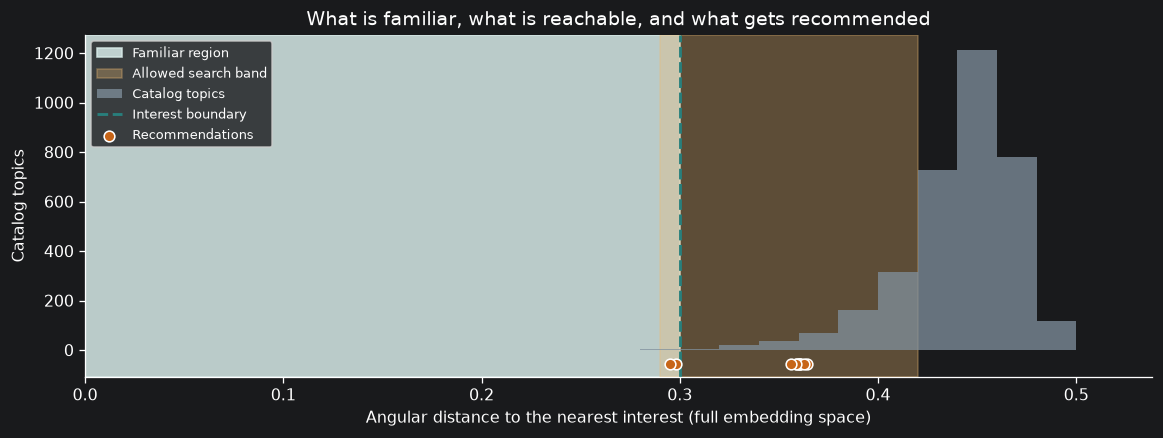

In [7]:
def plot_distance_band(seeds, selected, radius, expansion, overlap):
    scored = score_catalog(topics, topic_vectors, interests=[f"Interest {i}" for i in range(len(seeds))],
                           interest_vectors=seeds)
    distances = np.array([row["distance"] for row in scored])
    lower, upper = max(0, radius - overlap), min(1, radius + expansion)
    fig, ax = plt.subplots(figsize=(10, 3.7), layout="constrained")
    ax.axvspan(0, radius, color="#d8ebe9", alpha=0.85, label="Familiar region")
    ax.axvspan(lower, upper, color="#edba72", alpha=0.32, label="Allowed search band")
    counts, _, _ = ax.hist(distances, bins=np.linspace(0, 1, 51), color="#81919e", alpha=0.75, label="Catalog topics")
    peak_count = max(float(counts.max()), 1.0)
    ax.axvline(radius, color="#287f7c", linewidth=1.8, linestyle="--", label="Interest boundary")
    if selected:
        ax.scatter([row["distance"] for row in selected], np.full(len(selected), -0.045 * peak_count),
                   color="#c76518", s=45, edgecolors="white", zorder=4, label="Recommendations")
    ax.set(xlim=(0, min(1, max(upper + 0.035, distances.max() + 0.035))),
           ylim=(-0.09 * peak_count, None), xlabel="Angular distance to the nearest interest (full embedding space)",
           ylabel="Catalog topics", title="What is familiar, what is reachable, and what gets recommended")
    ax.legend(loc="upper left", fontsize=8, frameon=True)
    return fig


fig = plot_distance_band(interest_vectors, recommendations, RADIUS, EXPANSION, OVERLAP)
plt.show()

## 6. Experiment interactively

Start with **Balanced**. Presets fill the sliders; you can then adjust individual values. Larger radius excludes more of the closest material; larger expansion reaches farther out. These settings affect this panel without overwriting the experiment variables above.

Click **Explore again** for a small variation. Enable **Repeatable** to keep the same result for a fixed seed. Set randomness to zero for entirely deterministic ranking.

In [8]:
PRESETS = {
    "Close": dict(radius=0.24, expansion=0.05, overlap=0.015, diversity=0.15),
    "Balanced": dict(radius=0.28, expansion=0.07, overlap=0.015, diversity=0.20),
    "Broader": dict(radius=0.32, expansion=0.09, overlap=0.02, diversity=0.25),
}
preset_input = widgets.Dropdown(options=list(PRESETS), value="Balanced", description="Preset:")
interest_input = widgets.Textarea(value=", ".join(interests), description="Interests:",
                                   layout=widgets.Layout(width="650px", height="55px"))
slider_style = {"description_width": "130px"}
def control(label, value, maximum, step=0.005):
    return widgets.FloatSlider(value=value, min=0, max=maximum, step=step,
                               description=label, readout_format=".3f", continuous_update=False,
                               style=slider_style, layout=widgets.Layout(width="560px"))
radius_input = control("Interest radius", RADIUS, 0.5)
expansion_input = control("Expansion", EXPANSION, 0.25)
overlap_input = control("Familiar overlap", OVERLAP, 0.08)
diversity_input = control("Diversity", DIVERSITY, 0.6, step=0.01)
randomness_input = control("Randomness", RANDOMNESS, 0.10)
repeatable_input = widgets.Checkbox(value=False, description="Repeatable")
seed_input = widgets.BoundedIntText(value=SEED, min=0, max=2**31-1, description="Seed:")
explore_button = widgets.Button(description="Explore again", button_style="primary", icon="search")
interactive_output = widgets.Output()
last_run = {}


def apply_preset(change):
    settings = PRESETS[change["new"]]
    radius_input.value = settings["radius"]
    expansion_input.value = settings["expansion"]
    overlap_input.value = settings["overlap"]
    diversity_input.value = settings["diversity"]


def on_explore(_):
    explore_button.disabled = True
    try:
        with interactive_output:
            interactive_output.clear_output(wait=True)
            try:
                inputs = parse_interests(interest_input.value)
                seeds = model.encode(interest_texts(inputs, topics), normalize_embeddings=True, show_progress_bar=False)
                settings = dict(radius=radius_input.value, expansion=expansion_input.value,
                                overlap=overlap_input.value, top_k=TOP_K, diversity=diversity_input.value,
                                randomness=randomness_input.value,
                                seed=seed_input.value if repeatable_input.value else None)
                rows = recommend(topics, topic_vectors, inputs, seeds, **settings)
                last_run.clear()
                last_run.update(inputs=inputs, settings=settings, results=rows)
                show_parameter_compass(inputs, seeds, settings["radius"], settings["expansion"], settings["overlap"])
                display(Markdown("**You may also be interested in**"))
                show_recommendations(rows, TOP_K)
                plot_distance_band(seeds, rows, settings["radius"], settings["expansion"], settings["overlap"])
                plt.show()
            except ValueError as error:
                last_run.clear()
                print(str(error))
    finally:
        explore_button.disabled = False


preset_input.observe(apply_preset, names="value")
explore_button.on_click(on_explore)
display(widgets.VBox([interest_input, preset_input, radius_input, expansion_input, overlap_input,
                      diversity_input, randomness_input, widgets.HBox([repeatable_input, seed_input]),
                      explore_button, interactive_output]))

In [9]:
# Compare presets with the same interests and no random variation.
preset_comparison = []
for name, settings in PRESETS.items():
    rows = recommend(topics, topic_vectors, interests, interest_vectors,
                     **settings, top_k=TOP_K, randomness=0)
    preset_comparison.append({"Preset": name, "Results": len(rows),
                              "Allowed distances": f"{settings['radius']-settings['overlap']:.3f}–{settings['radius']+settings['expansion']:.3f}",
                              "Example topics": "; ".join(r["topic"] for r in rows[:4])})
display(pd.DataFrame(preset_comparison))

,Preset,Results,Allowed distances,Example topics
0,Close,3,0.225–0.290,Computational complexity theory; Association for Computing Machinery; Computer programming
1,Balanced,10,0.265–0.350,Control engineering; Data science; Information science; Computing
2,Broader,10,0.300–0.410,Cozy games; Mathematical optimization; abstraction; National Basketball Association


## 7. Sweep the exploration distance

Hold the interests, radius and overlap fixed. Compare which topics appear as more outward distance becomes acceptable. Mean distance can fluctuate because the catalog is discrete and diversity also affects selection; strict monotonicity is not guaranteed.

This sweep disables randomness so differences come from expansion and diversity only.

,Expansion,Results,Mean distance,Domains represented,Example topics
0,0.02,6,0.3073,3,Data science; Control engineering; Information science; Esports
1,0.04,10,0.3152,3,Computing; Applied mathematics; Computer program; Computability theory
2,0.07,10,0.3270,4,Software engineering; Premier League; Video game history; Computer security
3,0.10,10,0.3391,4,Computer network; Rugby league; P versus NP problem; behaviorism
4,0.15,10,0.3605,5,positivism; Cryptography; Pachisi; Algorithmic fairness


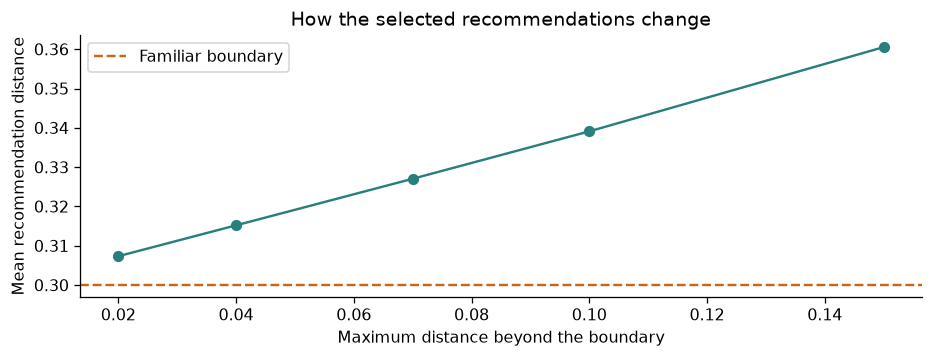

In [10]:
sweep_rows = []
for width in [0.02, 0.04, 0.07, 0.10, 0.15]:
    rows = recommend(topics, topic_vectors, interests, interest_vectors,
                     radius=RADIUS, expansion=width, overlap=OVERLAP,
                     top_k=TOP_K, diversity=DIVERSITY, randomness=0)
    sweep_rows.append({
        "Expansion": width,
        "Results": len(rows),
        "Mean distance": np.mean([row["distance"] for row in rows]) if rows else np.nan,
        "Domains represented": len({row["domain"] for row in rows}),
        "Example topics": "; ".join(row["topic"] for row in rows[:4]),
    })
sweep = pd.DataFrame(sweep_rows)
display(sweep.round(4))
fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
ax.plot(sweep["Expansion"], sweep["Mean distance"], "o-", color="#287f7c")
ax.axhline(RADIUS, linestyle="--", color="#c76518", label="Familiar boundary")
ax.set(xlabel="Maximum distance beyond the boundary", ylabel="Mean recommendation distance",
       title="How the selected recommendations change")
ax.legend()
plt.show()

## 8. Optional: a 2D view of the embedding space

PCA compresses 768 dimensions to two. **This picture distorts distances and is not used for search.** No exact neighborhood boundaries are drawn here. Use the distance plot above to verify eligibility.

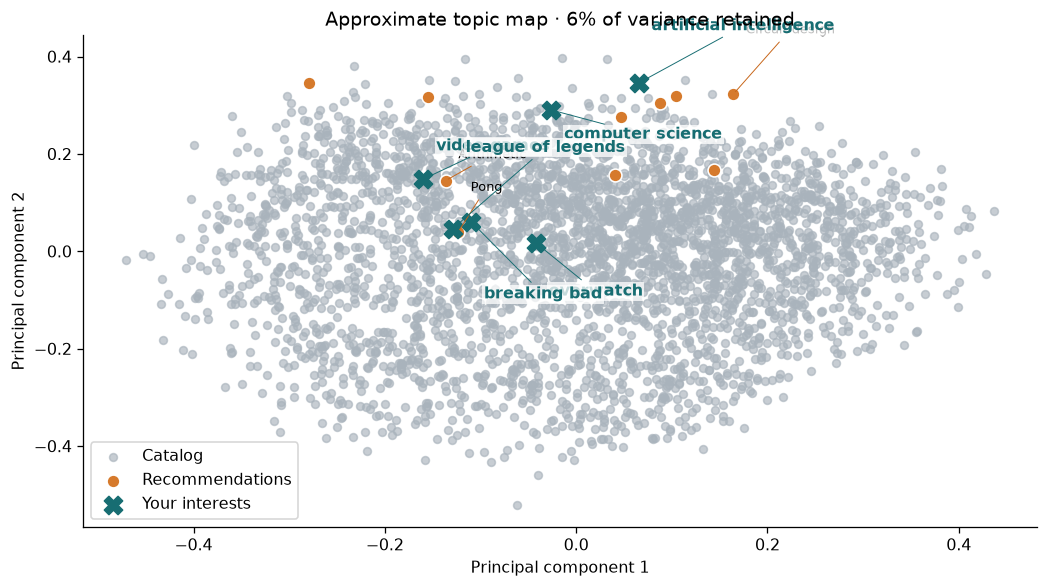

In [11]:
SHOW_PROJECTION = True
if SHOW_PROJECTION:
    combined = np.vstack([topic_vectors, interest_vectors])
    centered = combined - combined.mean(axis=0)
    _, singular_values, directions = np.linalg.svd(centered, full_matrices=False)
    projection = centered @ directions[:2].T
    retained = (singular_values[:2] ** 2).sum() / (singular_values ** 2).sum()
    fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
    ax.scatter(*projection[:len(topics)].T, s=24, color="#a9b3bc", alpha=0.65, label="Catalog")
    if recommendations:
        indices = [row["catalog_index"] for row in recommendations]
        ax.scatter(*projection[indices].T, s=65, color="#d67a2c", edgecolors="white", label="Recommendations")
        for offset, row in enumerate(recommendations[:3]):
            xy = projection[row["catalog_index"]]
            ax.annotate(row["topic"], xy=xy, xytext=(8, 14 + offset * 12), textcoords="offset points",
                        fontsize=8, arrowprops={"arrowstyle": "-", "color": "#c76518", "lw": 0.6})
    ax.scatter(*projection[len(topics):].T, marker="X", s=130, color="#176d72", label="Your interests")
    for i, phrase in enumerate(interests):
        ax.annotate(phrase, projection[len(topics) + i], xytext=(8, (18 + 15 * (i // 2)) * (1 if i % 2 == 0 else -1)),
                    textcoords="offset points", fontweight="bold", color="#176d72",
                    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1},
                    arrowprops={"arrowstyle": "-", "color": "#176d72", "lw": 0.6})
    ax.set(xlabel="Principal component 1", ylabel="Principal component 2",
           title=f"Approximate topic map · {retained:.0%} of variance retained")
    ax.legend(loc="best")
    plt.show()

## 9. Small variations, unchanged boundaries

Each seed adds one fixed, bounded score perturbation per candidate for that run. It may change near-tied selections and ordering, but cannot pull in a topic outside the band. The same seed is reproducible with the same inputs, model and catalog; randomness zero gives deterministic ranking regardless of seed.

In [12]:
variation_rows = []
for trial_seed in [7, 42, 123]:
    rows = recommend(topics, topic_vectors, interests, interest_vectors, radius=RADIUS,
                     expansion=EXPANSION, overlap=OVERLAP, top_k=TOP_K, diversity=DIVERSITY,
                     randomness=RANDOMNESS, seed=trial_seed)
    variation_rows.append({"Seed": trial_seed, "First recommendations": "; ".join(r["topic"] for r in rows[:5])})
display(pd.DataFrame(variation_rows))

,Seed,First recommendations
0,7,Mathematical analysis; Pong; Data structure; Circuit design; Computable function
1,42,Arithmetic; Pong; Circuit design; Mathematical optimization; Data structure
2,123,Arithmetic; Cooperative games; Coding theory; Computable function; Natural language processing


<a id="specific-discovery"></a>
## 10. Specific ideas and feedback

The second stage follows real **Wikipedia category memberships**, with **Wikidata IDs and descriptions**, to retrieve concrete ideas. The fixed catalog covers all **23 original domains**, with **three navigation areas and 160 eligible concepts per domain**. Within each domain, selection spreads entries across its areas and includes **two reviewed entry points at each of three levels**.

Every domain uses the same traversal rule: start one category level deep, then allow one extra level if it cannot fill its budget. There is no special treatment for any example topic. The chart below shows the actual candidate coverage; individual recommendation lists still follow your interests and distance settings.

Source paths explain where an item came from, not prerequisites or difficulty. Reading levels and hooks are editorial annotations for introductory treatments. Other items remain explicitly unrated. The snapshot is a balanced sample of English Wikipedia, not a complete or culturally neutral map of knowledge.


3,642 specific concepts · 69 areas · 3,919 sourced edges
132 concepts have reviewed entry-point levels; the rest are unrated.


,Domain,Concepts,Reviewed entry points
0,Biology & nature,160,6
1,Chemistry & materials,160,6
2,Computing & information,160,6
3,Earth & environment,160,6
4,Economics & organizations,160,6
5,Engineering & transport,160,6
6,Food & agriculture,160,6
7,Games & sports,160,6
8,Geography & travel,160,6
9,Health & medicine,160,6


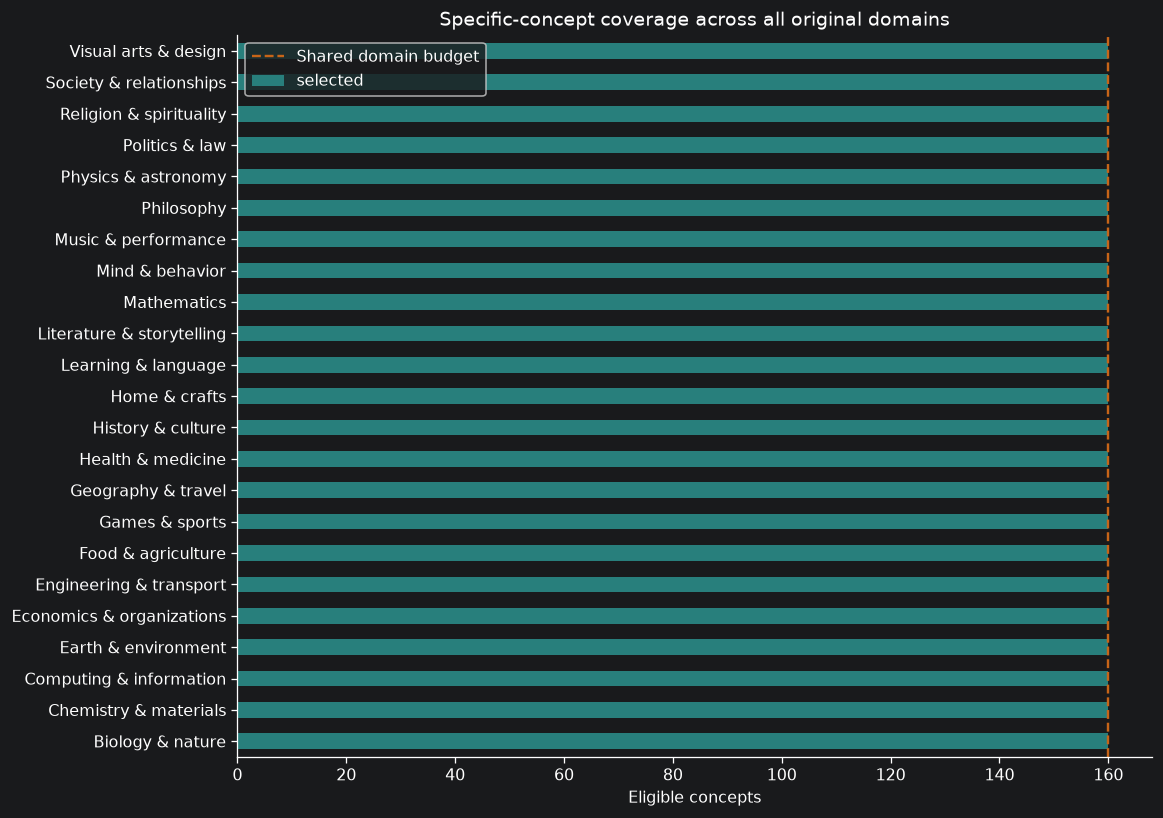

Counts use the same area selections as the recommender; shared concepts can belong to more than one domain.


In [8]:
from graph_explorer import load_graph, graph_concepts, graph_candidates, select_areas, recommend_specific
from feedback import new_profile, set_feedback
from discovery_widgets import DiscoveryPanel, LEVELS

discovery_graph = load_graph()
discovery_concepts = graph_concepts(discovery_graph)
discovery_vectors = model.encode(topic_texts(discovery_concepts), normalize_embeddings=True, show_progress_bar=False)
area_vectors = model.encode(topic_texts(discovery_graph["areas"]), normalize_embeddings=True, show_progress_bar=False)
reviewed_count = sum(n.get("level") is not None for n in discovery_concepts)
print(f"{len(discovery_concepts):,} specific concepts · {len(discovery_graph['areas'])} areas · {len(discovery_graph['edges']):,} sourced edges")
print(f"{reviewed_count} concepts have reviewed entry-point levels; the rest are unrated.")
coverage = pd.DataFrame(discovery_graph["metadata"]["balance"]["coverage"])
display(coverage[["domain", "selected", "reviewed"]].rename(columns={
    "domain": "Domain", "selected": "Concepts", "reviewed": "Reviewed entry points"}))
fig, ax = plt.subplots(figsize=(10, 7), layout="constrained")
coverage.set_index("domain")["selected"].plot.barh(ax=ax, color="#287f7c")
ax.axvline(discovery_graph["metadata"]["balance"]["concepts_per_domain"],
           color="#c76518", linestyle="--", label="Shared domain budget")
ax.set(title="Specific-concept coverage across all original domains", xlabel="Eligible concepts", ylabel="")
ax.legend()
plt.show()
print("Counts use the same area selections as the recommender; shared concepts can belong to more than one domain.")

In [9]:
def specific_table(rows):
    return pd.DataFrame([{
        "Specific idea": r["topic"],
        "Entry point": r.get("hook") or r["description"],
        "Through area": r["area"],
        "Distance": round(r["distance"], 3),
        "Level estimate": LEVELS[r.get("level")],
        "Exploration place": r["exploration_pick"],
    } for r in rows])

broad_for_graph = recommend(topics, topic_vectors, interests, interest_vectors,
                            radius=RADIUS, expansion=EXPANSION, overlap=OVERLAP,
                            diversity=DIVERSITY, top_k=24, randomness=0)
area_queries = [interest_vectors]
if broad_for_graph:
    area_queries.append(topic_vectors[[r["catalog_index"] for r in broad_for_graph]])
selected_areas = select_areas(discovery_graph["areas"], area_vectors, np.vstack(area_queries), limit=8)
specific_rows = recommend_specific(discovery_graph, discovery_vectors, interests, interest_vectors,
                                  area_ids=selected_areas, profile=new_profile(), radius=RADIUS,
                                  expansion=EXPANSION, overlap=OVERLAP, top_k=TOP_K,
                                  diversity=DIVERSITY, randomness=RANDOMNESS, seed=SEED,
                                  exploration_fraction=0.30)
if specific_rows:
    display(specific_table(specific_rows))
    print("Example source paths:")
    for row in specific_rows[:3]:
        print(" → ".join(row["graph_path"]))
        print(row.get("source_url", ""))
else:
    print("No specific concepts in this snapshot fit the current band. Try a slightly wider expansion or other interests.")

,Specific idea,Entry point,Through area,Distance,Level estimate,Exploration place
0,Dataflow programming,programming paradigm that models program as a directed graph of data flow between operations,Computer programming,0.359,Not yet reviewed,True
1,Real-time strategy game,"strategy video game subgenre in which all players play simultaneously, rather than taking turns",Video games,0.361,Not yet reviewed,True
2,Lawbot,programmed bot to automate legal tasks,Artificial intelligence,0.359,Not yet reviewed,True
3,Parameterized complexity,branch of computational complexity theory,Computer science,0.358,Not yet reviewed,False
4,Cat in the Box,2022 board game,Mathematical puzzles,0.376,Not yet reviewed,False
5,Programming by demonstration,technique for teaching a computer or a robot new behaviors,Computer programming,0.356,Not yet reviewed,False
6,Nondeterministic algorithm,model in computer science,Computer science,0.360,Not yet reviewed,False
7,Art game,video game designed to emphasize art or whose structure is intended to produce some kind of reaction in it...,Video games,0.360,Not yet reviewed,False
8,Trustworthy AI,"AI standards for robustness, transparency and data privacy",Artificial intelligence,0.367,Not yet reviewed,False
9,Cliffhanger,Analyze how withholding a resolution changes a story's pace and tension.,Storytelling,0.384,Some background helpful,False


Example source paths:
Computer programming → Programming paradigms → Dataflow programming
https://www.wikidata.org/wiki/Q1172543
Video game terminology → Video game genres → Real-time strategy game
https://www.wikidata.org/wiki/Q208189
Artificial intelligence → Argument technology → Lawbot
https://www.wikidata.org/wiki/Q30694291


### Try the feedback loop

Click **Explore specific ideas**, then rate any card. You can combine **Curious** with **Already know**, **Too basic**, or **Too hard**. Saving reranks the current search immediately, with the same random draw and distance settings.

- **Curious** boosts that concept and modestly favors its source area.
- **Already know** excludes that concept; it does not mark its entire subject as mastered.
- **Too basic / too hard** adjusts the preferred challenge in that branch. It favors suitable reviewed levels; unrated concepts remain neutral. The exact mismatched entry point is downranked.
- **Explore less-seen areas** reserves a fraction of results from the least-shown eligible areas. Sparse coverage may leave this reservation partly unfilled; distance and overlap limits still apply.

Feedback is saved locally in `.local/feedback.json`, which Git ignores. **Undo last feedback** reverses the latest edit; the saved-feedback panel lets you clear a rating even after a known concept disappears. Exposure counts are updated on Explore clicks. Nothing is saved by the examples above or below.

In [10]:
discovery_panel = DiscoveryPanel(
    discovery_graph, discovery_vectors, area_vectors, model, topics, topic_vectors,
    interests=interests,
    settings=dict(radius=RADIUS, expansion=EXPANSION, overlap=OVERLAP, top_k=TOP_K,
                  diversity=DIVERSITY, randomness=RANDOMNESS, seed=SEED),
)
discovery_panel.display()

### Inspect a before-and-after example

This experiment uses **computer science** and temporary in-memory feedback. The generous example band helps expose a range of concrete ideas. Your live profile and chosen interests stay separate from this experiment.

Compare the unpersonalized list with one where the first concept is already known. Then simulate **Curious + Too hard** on a reviewed entry from the eligible graph pool and inspect the reranked ideas. Feedback changes ranking; it never changes the eligible distance band.

In [16]:
example_interests = ["computer science"]
example_vectors = model.encode(interest_texts(example_interests, topics), normalize_embeddings=True, show_progress_bar=False)
example_areas = select_areas(discovery_graph["areas"], area_vectors, example_vectors, limit=5)
example_settings = dict(radius=0.26, expansion=0.18, overlap=0.01, top_k=10,
                        diversity=0.20, randomness=0, exploration_fraction=0.30)
example_before = recommend_specific(discovery_graph, discovery_vectors, example_interests, example_vectors,
                                    area_ids=example_areas, profile=new_profile(), **example_settings)
feedback_comparison = []
if example_before:
    feedback_comparison.append({"Feedback": "None", "First ideas": "; ".join(r["topic"] for r in example_before[:4])})
    known_example = new_profile()
    first = example_before[0]
    set_feedback(known_example, first["id"], known=True, area_ids=[first["area_id"]])
    after_known = recommend_specific(discovery_graph, discovery_vectors, example_interests, example_vectors,
                                     area_ids=example_areas, profile=known_example, **example_settings)
    assert first["id"] not in {r["id"] for r in after_known}
    feedback_comparison.append({"Feedback": "Already know: " + first["topic"], "First ideas": "; ".join(r["topic"] for r in after_known[:4])})
    # Pick a genuinely reviewed, eligible entry for the difficulty demonstration.
    reached = {r["id"]: r for r in graph_candidates(discovery_graph, example_areas)}
    reviewed_examples = [r for r in score_catalog(discovery_concepts, discovery_vectors, example_interests, example_vectors)
                         if r["id"] in reached and r.get("level") in (2, 3)
                         and 0.25 <= r["distance"] <= 0.44]
    if reviewed_examples:
        rated = min(reviewed_examples, key=lambda r: abs(r["distance"] - 0.35))
        rated_area = reached[rated["id"]]["area_ids"][0]
        difficulty_example = new_profile()
        set_feedback(difficulty_example, rated["id"], curious=True, difficulty="too_hard",
                     level=rated["level"], area_ids=[rated_area])
        after_difficulty = recommend_specific(discovery_graph, discovery_vectors, example_interests, example_vectors,
                                              area_ids=example_areas, profile=difficulty_example, **example_settings)
        feedback_comparison.append({"Feedback": "Curious + too hard: " + rated["topic"],
                                    "First ideas": "; ".join(r["topic"] for r in after_difficulty[:4])})
        print(f"Difficulty example: {rated['topic']} — {LEVELS[rated['level']]}.")
        print(rated.get("hook") or rated["description"])
    display(pd.DataFrame(feedback_comparison))
    display(specific_table(example_before))
    print("All examples use the same 0.250–0.440 distance band.")
else:
    print("This snapshot has no eligible computer-science examples in the selected band.")

Difficulty example: Interactive proof system — Technical treatment.
Study how a verifier can gain confidence through a conversation with a powerful prover.


,Feedback,First ideas
0,None,Programming by permutation; Medical algorithm; Limits of computation; Graph (abstract data type)
1,Already know: Programming by permutation,Medical algorithm; Purely functional programming; Limits of computation; Graph (abstract data type)
2,Curious + too hard: Interactive proof system,Unary language; Medical algorithm; Programming by permutation; Limits of computation


,Specific idea,Entry point,Through area,Distance,Level estimate,Exploration place
0,Programming by permutation,approach to software development,Computer programming,0.348,Not yet reviewed,True
1,Medical algorithm,algorithmic operation utilized in the study of medical information pertaining to health care,Artificial intelligence,0.348,Not yet reviewed,True
2,Limits of computation,"physical and practical limits to the amount of computation or data storage with a given amount of mass, vo...",Computer science,0.344,Not yet reviewed,True
3,Graph (abstract data type),abstract data type in computer science,Graph theory,0.364,Not yet reviewed,False
4,Partitioned global address space,parallel programming model in computer science,Computer programming,0.347,Not yet reviewed,False
5,Information space analysis,machine intelligence method,Artificial intelligence,0.353,Not yet reviewed,False
6,Unary language,formal language in computational complexity theory,Computer science,0.346,Not yet reviewed,False
7,Algorithmic composition,technique of using algorithms to create music,Music theory,0.327,Not yet reviewed,False
8,Purely functional programming,programming paradigm that treats all computation as the evaluation of mathematical functions,Computer programming,0.347,Not yet reviewed,False
9,Algorithm characterizations,attempts to formalize the concept of algorithms,Computer science,0.345,Not yet reviewed,False


All examples use the same 0.250–0.440 distance band.


## What this demo establishes

You can inspect how a fixed vocabulary, an explicit interest boundary and a tunable search band change recommendations. The input seeds, model, distances, sourced graph paths and feedback rules are visible and editable.

Topic expansion is not the same as exposure to different viewpoints, and embedding distance alone does not prove that a recommendation is useful. Those claims would need separate evaluation with people. The catalog and embedding model also influence what can be discovered.

**Next experiments:** change `INTERESTS` (for example to `["machine learning", "photography"]`), adjust the assumed radius, or extend the catalog and rerun. The `recommend(...)` function in `explorer.py` is independent of this notebook and can later be called by a website backend.

References: [embedding model](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) · [semantic search](https://www.sbert.net/examples/sentence_transformer/applications/semantic-search/README.html).